In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import shap

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("shap:", shap.__version__)

numpy: 2.4.6
pandas: 3.0.3
xarray: 2026.7.0
shap: 0.51.0


# 读入ERA5

In [2]:
data_path = Path("../data/china_temperature.nc")

ds = xr.open_dataset(data_path)

ds
print(ds.data_vars)
print(ds.dims)
print(ds.coords)

Data variables:
    t2m      (valid_time, latitude, longitude) float32 81MB ...
FrozenMappingWarningOnValuesAccess({'valid_time': 559, 'latitude': 145, 'longitude': 249})
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1980-01-01 ... 2026-07-01
    expver      (valid_time) <U4 9kB ...
  * latitude    (latitude) float64 1kB 54.0 53.75 53.5 53.25 ... 18.5 18.25 18.0
  * longitude   (longitude) float64 2kB 73.0 73.25 73.5 ... 134.5 134.8 135.0
    number      int64 8B ...


In [3]:
temp = ds["t2m"]
temp

<xarray.DataArray 't2m' (valid_time: 559, latitude: 145, longitude: 249)> Size: 81MB
[20182695 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1980-01-01 ... 2026-07-01
    expver      (valid_time) <U4 9kB ...
  * latitude    (latitude) float64 1kB 54.0 53.75 53.5 53.25 ... 18.5 18.25 18.0
  * longitude   (longitude) float64 2kB 73.0 73.25 73.5 ... 134.5 134.8 135.0
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      36105
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [4]:
print(temp.valid_time.values[:10])
print(temp.valid_time.values[-10:])
print("Number of time steps:", len(temp.valid_time))

['1980-01-01T00:00:00.000000000' '1980-02-01T00:00:00.000000000'
 '1980-03-01T00:00:00.000000000' '1980-04-01T00:00:00.000000000'
 '1980-05-01T00:00:00.000000000' '1980-06-01T00:00:00.000000000'
 '1980-07-01T00:00:00.000000000' '1980-08-01T00:00:00.000000000'
 '1980-09-01T00:00:00.000000000' '1980-10-01T00:00:00.000000000']
['2025-10-01T00:00:00.000000000' '2025-11-01T00:00:00.000000000'
 '2025-12-01T00:00:00.000000000' '2026-01-01T00:00:00.000000000'
 '2026-02-01T00:00:00.000000000' '2026-03-01T00:00:00.000000000'
 '2026-04-01T00:00:00.000000000' '2026-05-01T00:00:00.000000000'
 '2026-06-01T00:00:00.000000000' '2026-07-01T00:00:00.000000000']
Number of time steps: 559


In [5]:
print(temp.attrs)
temp_c = temp - 273.15
temp_c.attrs["units"] = "°C"

{'GRIB_paramId': np.int64(167), 'GRIB_dataType': 'an', 'GRIB_numberOfPoints': np.int64(36105), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'instant', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(249), 'GRIB_Ny': np.int64(145), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 't2m', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(54.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(18.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(73.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(135.0), 'GRIB_missingValue': np.float64(3.4028234663852886e+38), 'GRIB_name': '2 metre temperatu

# MEAN TEMPERATURE

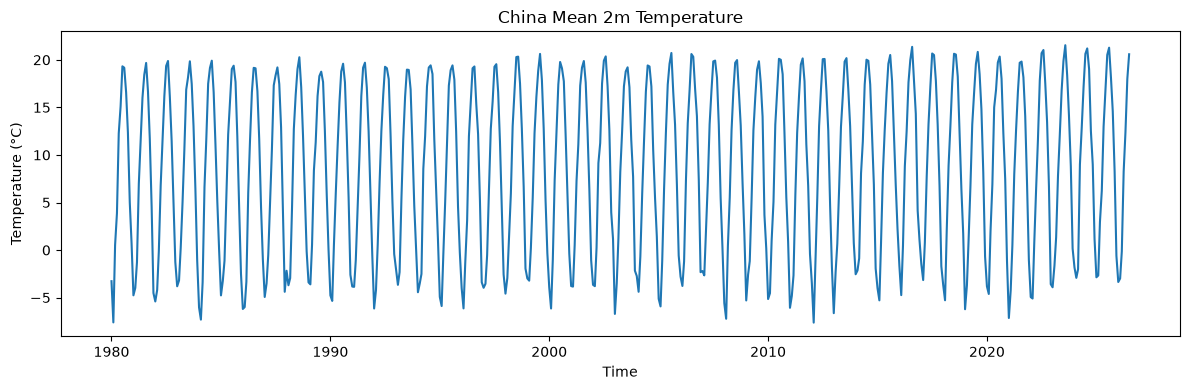

In [6]:
lat_name = "latitude"

weights = np.cos(np.deg2rad(temp_c[lat_name]))

china_mean_temp = temp_c.weighted(weights).mean(
    dim=("latitude", "longitude")
)

china_mean_temp
plt.figure(figsize=(12, 4))

china_mean_temp.plot()

plt.title("China Mean 2m Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

In [7]:
# PANDAS
df = china_mean_temp.to_dataframe(name="temperature").reset_index()

df.head()
df["valid_time"] = pd.to_datetime(df["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

df.head()

,valid_time,number,expver,temperature
0,1980-01-01,0,0001,-3.273281
1,1980-02-01,0,0001,-7.607510
2,1980-03-01,0,0001,0.530283
3,1980-04-01,0,0001,3.874058
4,1980-05-01,0,0001,12.269591


In [8]:
#前 80% → training,后 20% → testing
split_idx = int(len(df) * 0.8)

split_time = df.loc[split_idx, "valid_time"]

print("Split time:", split_time)

Split time: 2017-04-01 00:00:00


# 计算 climatology

In [9]:
#加入月份
df["month"] = df["valid_time"].dt.month
#只用 training period
train_raw = df[df["valid_time"] < split_time]
#计算每个月平均 climatology
monthly_climatology = (
    train_raw
    .groupby("month")["temperature"]
    .mean()
)
#把 climatology 映射回整个 dataset
df["climatology"] = df["month"].map(monthly_climatology)
#计算 anomaly
df["temp_anomaly"] = (
    df["temperature"] - df["climatology"]
)


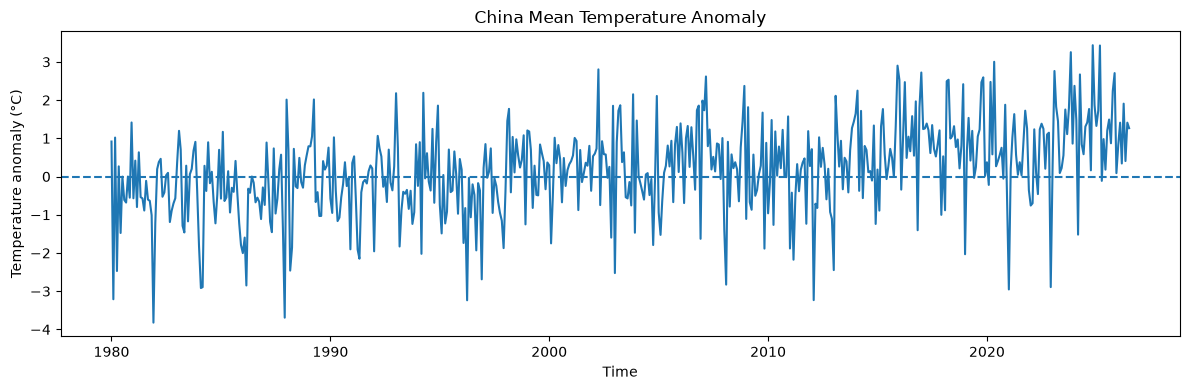

In [10]:
#画 anomaly
plt.figure(figsize=(12, 4))

plt.plot(
    df["valid_time"],
    df["temp_anomaly"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("China Mean Temperature Anomaly")
plt.xlabel("Time")
plt.ylabel("Temperature anomaly (°C)")

plt.tight_layout()
plt.show()

# 构造MLfeatures

In [11]:
#输入当前月、前一个月、前两个月
df["temp_anom_t"] = df["temp_anomaly"]

df["temp_anom_tminus1"] = (
    df["temp_anomaly"].shift(1)
)

df["temp_anom_tminus2"] = (
    df["temp_anomaly"].shift(2)
)
#预测next month anomaly
df["next_month_anom"] = (
    df["temp_anomaly"].shift(-1)
)
#建立classifacation target
df["warm_next_month"] = (
    df["next_month_anom"] > 0
).astype(int)
#最后一个月之后没有 future month,`.dropna()`只要上面任意一列存在空值 NaN，就把这一整行直接删掉
feature_cols = [
    "temp_anom_t",
    "temp_anom_tminus1",
    "temp_anom_tminus2"
]
df_ml = df.dropna(
    subset=feature_cols + ["next_month_anom"]
).copy()

In [12]:
#temporal split
train_df = df_ml[
    df_ml["valid_time"] < split_time
].copy()

test_df = df_ml[
    df_ml["valid_time"] >= split_time
].copy()

X_train = train_df[feature_cols]
y_train = train_df["warm_next_month"]

X_test = test_df[feature_cols]
y_test = test_df["warm_next_month"]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "Train positive ratio:",
    y_train.mean()
)

print(
    "Test positive ratio:",
    y_test.mean()
)

Training samples: 445
Testing samples: 111
Train positive ratio: 0.5191011235955056
Test positive ratio: 0.8648648648648649


In [13]:
#建立 Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])
logistic_model.fit(
    X_train,
    y_train
)
y_pred_logistic = logistic_model.predict(
    X_test
)

y_prob_logistic = logistic_model.predict_proba(
    X_test
)[:, 1]

#计算 metrics
def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred
        ),
        "Recall": recall_score(
            y_true,
            y_pred
        ),
        "F1": f1_score(
            y_true,
            y_pred
        ),
        "ROC AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "Brier Score": brier_score_loss(
            y_true,
            y_prob
        )
    }

    return metrics

logistic_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

logistic_metrics


{'Model': 'Logistic Regression',
 'Accuracy': 0.8018018018018018,
 'Balanced Accuracy': 0.4635416666666667,
 'Precision': 0.8557692307692307,
 'Recall': 0.9270833333333334,
 'F1': 0.89,
 'ROC AUC': 0.5527777777777777,
 'Brier Score': 0.17694252127713608}

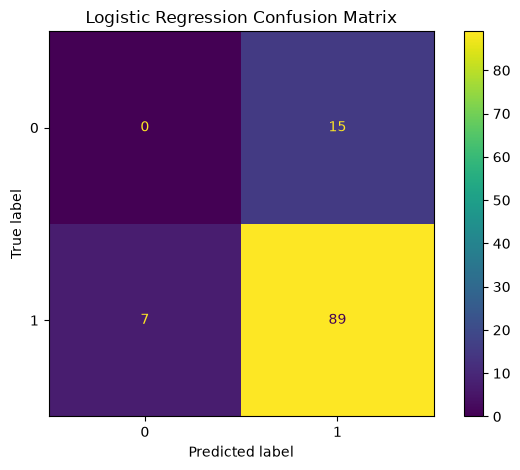

In [14]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [15]:
#random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
#训练
rf_model.fit(
    X_train,
    y_train
)
#预测
y_pred_rf = rf_model.predict(
    X_test
)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]
#评价
rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

rf_metrics

{'Model': 'Random Forest',
 'Accuracy': 0.6846846846846847,
 'Balanced Accuracy': 0.4239583333333333,
 'Precision': 0.8426966292134831,
 'Recall': 0.78125,
 'F1': 0.8108108108108109,
 'ROC AUC': 0.4916666666666667,
 'Brier Score': 0.19062791900977225}

In [16]:
metrics_df = pd.DataFrame([
    logistic_metrics,
    rf_metrics
])

metrics_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Brier Score
0,Logistic Regression,0.801802,0.463542,0.855769,0.927083,0.890000,0.552778,0.176943
1,Random Forest,0.684685,0.423958,0.842697,0.781250,0.810811,0.491667,0.190628


In [17]:
#加入 persistence baseline
persistence_pred = (
    X_test["temp_anom_t"] > 0
).astype(int)
#计算
persistence_accuracy = accuracy_score(
    y_test,
    persistence_pred
)

print(
    "Persistence accuracy:",
    persistence_accuracy
)


Persistence accuracy: 0.7837837837837838


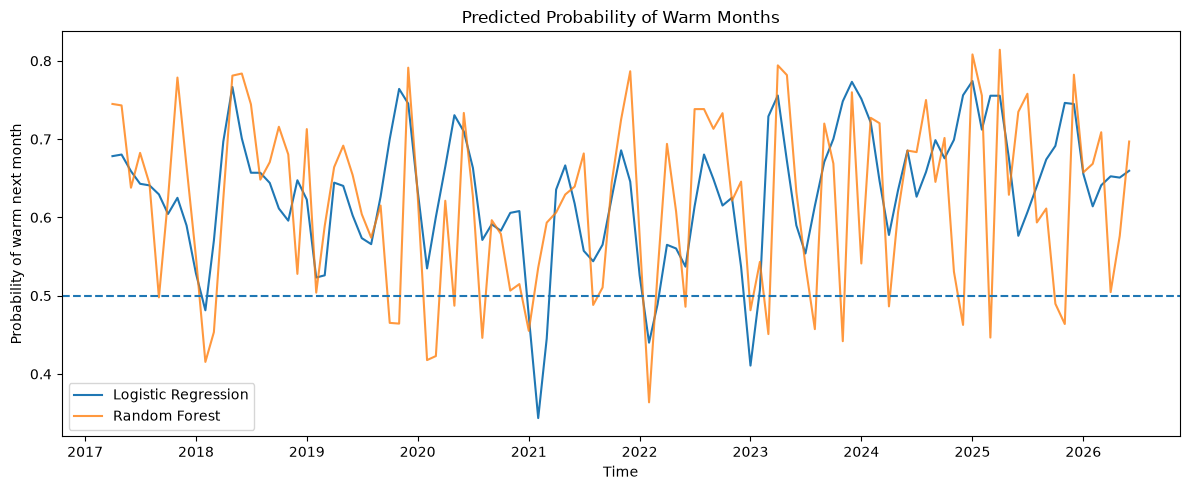

In [18]:
#看预测概率
prediction_df = pd.DataFrame({
    "valid_time": test_df["valid_time"].values,
    "observed": y_test.values,
    "logistic_probability": y_prob_logistic,
    "rf_probability": y_prob_rf
})

plt.figure(figsize=(12, 5))

plt.plot(
    prediction_df["valid_time"],
    prediction_df["logistic_probability"],
    label="Logistic Regression"
)

plt.plot(
    prediction_df["valid_time"],
    prediction_df["rf_probability"],
    label="Random Forest",
    alpha=0.8
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.ylabel(
    "Probability of warm next month"
)

plt.xlabel("Time")

plt.title(
    "Predicted Probability of Warm Months"
)

plt.legend()

plt.tight_layout()
plt.show()

In [19]:
#Logistic Regression 的 coefficient
logistic_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": logistic_coefficients
})

coef_df


,Feature,Coefficient
0,temp_anom_t,0.139505
1,temp_anom_tminus1,0.250681
2,temp_anom_tminus2,0.177068


(111, 3, 2)


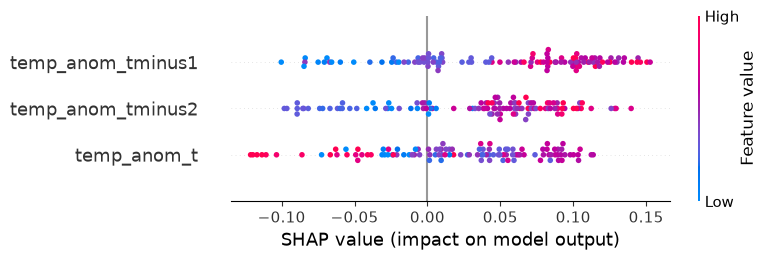

In [20]:
#SHAP
explainer = shap.Explainer(
    rf_model,
    X_train
)

shap_values = explainer(
    X_test
)

print(
    shap_values.values.shape
)
shap_class1 = shap_values.values[:, :, 1]
shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=feature_cols
)

# 保存结果

In [21]:
from pathlib import Path

Path("../results").mkdir(
    exist_ok=True
)

Path("../figures").mkdir(
    exist_ok=True
)
metrics_df.to_csv(
    "../results/model_metrics.csv",
    index=False
)